In [1]:
pip install pandas numpy matplotlib seaborn nltk wordcloud scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Admin\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Admin\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Admin\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\Admin\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Admin\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Admin\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Admin\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\Admin\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Admin\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Admin\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Admin\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\Admin\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [3]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
import pandas as pd

data = {
    "Review_ID": [1,2,3,4,5,6,7,8,9,10],
    
    "Customer_Name": [
        "Rahul","Priya","Arjun","Sneha","Kiran",
        "Ananya","Rohan","Meera","Varun","Divya"
    ],

    "Age": [24,28,31,22,35,27,30,26,29,23],

    "Gender": [
        "Male","Female","Male","Female","Male",
        "Female","Male","Female","Male","Female"
    ],

    "Restaurant_Name": [
        "Spice Hub","Pizza Town","Food Palace","Burger Spot",
        "Green Bowl","Coffee Corner","Tasty Treat",
        "Sushi World","Grill House","Sweet Treats"
    ],

    "Location": [
        "Bangalore","Mysore","Chennai","Bangalore","Hyderabad",
        "Pune","Delhi","Mumbai","Kochi","Bangalore"
    ],

    "Cuisine_Type": [
        "Indian","Italian","Chinese","Fast Food","Healthy",
        "Cafe","Indian","Japanese","BBQ","Dessert"
    ],

    "Food_Item": [
        "Biryani","Pizza","Noodles","Burger","Salad",
        "Coffee","Meals","Sushi","Chicken Grill","Cake"
    ],

    "Order_Type": [
        "Dine-in","Delivery","Takeaway","Delivery","Dine-in",
        "Dine-in","Delivery","Dine-in","Takeaway","Delivery"
    ],

    "Visit_Date": [
        "2026-01-05","2026-01-07","2026-01-10",
        "2026-01-12","2026-01-15","2026-01-18",
        "2026-01-20","2026-01-22","2026-01-25",
        "2026-01-28"
    ],

    "Rating": [5,2,4,1,5,4,3,5,2,5],

    "Review_Text": [
        "Food was delicious and service was excellent",
        "Pizza arrived late and was cold",
        "Good taste but waiting time was high",
        "Bad packaging and poor food quality",
        "Fresh food and peaceful environment",
        "Nice coffee but prices are expensive",
        "Food was okay but delivery was slow",
        "Amazing taste and great ambience",
        "Food quantity was less for the price",
        "Cake was fresh and delivered quickly"
    ],

    "Food_Quality": [
        "Excellent","Poor","Good","Poor","Excellent",
        "Good","Average","Excellent","Average","Excellent"
    ],

    "Taste": [
        "Spicy","Average","Delicious","Bad","Fresh",
        "Good","Average","Amazing","Good","Sweet"
    ],

    "Service_Rating": [5,2,3,1,5,4,3,5,2,5],

    "Staff_Behavior": [
        "Friendly","Average","Polite","Rude","Friendly",
        "Polite","Good","Friendly","Average","Friendly"
    ],

    "Cleanliness": [
        "Excellent","Good","Good","Average","Excellent",
        "Good","Good","Excellent","Good","Excellent"
    ],

    "Ambience": [
        "Good","NA","Average","NA","Excellent",
        "Good","NA","Excellent","Average","NA"
    ],

    "Waiting_Time_Min": [
        10,0,35,0,5,15,0,8,20,0
    ],

    "Price_Range": [
        "Medium","High","Medium","Low","High",
        "High","Medium","High","High","Medium"
    ],

    "Payment_Method": [
        "UPI","Card","Cash","UPI","Card",
        "UPI","Cash","Card","UPI","UPI"
    ],

    "Discount_Used": [
        "Yes","No","Yes","No","Yes",
        "No","No","Yes","No","Yes"
    ],

    "Delivery_Time_Min": [
        0,60,0,45,0,0,50,0,0,20
    ],

    "Delivery_Experience": [
        "NA","Poor","NA","Poor","NA",
        "NA","Average","NA","NA","Excellent"
    ],

    "Sentiment": [
        "Positive","Negative","Positive","Negative",
        "Positive","Positive","Neutral",
        "Positive","Negative","Positive"
    ],

    "Complaint_Type": [
        "None","Late Delivery","Waiting Time",
        "Food Quality","None","Price",
        "Delivery Delay","None","Quantity","None"
    ],

    "Recommended": [
        "Yes","No","Yes","No","Yes",
        "Yes","Yes","Yes","No","Yes"
    ],

    "Review_Length": [
        45,35,40,38,42,39,37,36,41,34
    ],

    "Customer_Type": [
        "Regular","New","Regular","New","Regular",
        "Regular","New","Regular","New","Regular"
    ],

    "Feedback_Source": [
        "App","Website","Google","App","Website",
        "Google","App","Website","Google","App"
    ]
}


df = pd.DataFrame(data)

print(df)

df.to_csv("Restaurant_Reviews.csv", index=False)

   Review_ID Customer_Name  Age  Gender Restaurant_Name   Location  \
0          1         Rahul   24    Male       Spice Hub  Bangalore   
1          2         Priya   28  Female      Pizza Town     Mysore   
2          3         Arjun   31    Male     Food Palace    Chennai   
3          4         Sneha   22  Female     Burger Spot  Bangalore   
4          5         Kiran   35    Male      Green Bowl  Hyderabad   
5          6        Ananya   27  Female   Coffee Corner       Pune   
6          7         Rohan   30    Male     Tasty Treat      Delhi   
7          8         Meera   26  Female     Sushi World     Mumbai   
8          9         Varun   29    Male     Grill House      Kochi   
9         10         Divya   23  Female    Sweet Treats  Bangalore   

  Cuisine_Type      Food_Item Order_Type  Visit_Date  ...  Payment_Method  \
0       Indian        Biryani    Dine-in  2026-01-05  ...             UPI   
1      Italian          Pizza   Delivery  2026-01-07  ...            Card  

In [5]:
df.head()

,Review_ID,Customer_Name,Age,Gender,Restaurant_Name,Location,Cuisine_Type,Food_Item,Order_Type,Visit_Date,...,Payment_Method,Discount_Used,Delivery_Time_Min,Delivery_Experience,Sentiment,Complaint_Type,Recommended,Review_Length,Customer_Type,Feedback_Source
0,1,Rahul,24,Male,Spice Hub,Bangalore,Indian,Biryani,Dine-in,2026-01-05,...,UPI,Yes,0,NA,Positive,None,Yes,45,Regular,App
1,2,Priya,28,Female,Pizza Town,Mysore,Italian,Pizza,Delivery,2026-01-07,...,Card,No,60,Poor,Negative,Late Delivery,No,35,New,Website
2,3,Arjun,31,Male,Food Palace,Chennai,Chinese,Noodles,Takeaway,2026-01-10,...,Cash,Yes,0,NA,Positive,Waiting Time,Yes,40,Regular,Google
3,4,Sneha,22,Female,Burger Spot,Bangalore,Fast Food,Burger,Delivery,2026-01-12,...,UPI,No,45,Poor,Negative,Food Quality,No,38,New,App
4,5,Kiran,35,Male,Green Bowl,Hyderabad,Healthy,Salad,Dine-in,2026-01-15,...,Card,Yes,0,NA,Positive,None,Yes,42,Regular,Website


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Review_ID            10 non-null     int64
 1   Customer_Name        10 non-null     str  
 2   Age                  10 non-null     int64
 3   Gender               10 non-null     str  
 4   Restaurant_Name      10 non-null     str  
 5   Location             10 non-null     str  
 6   Cuisine_Type         10 non-null     str  
 7   Food_Item            10 non-null     str  
 8   Order_Type           10 non-null     str  
 9   Visit_Date           10 non-null     str  
 10  Rating               10 non-null     int64
 11  Review_Text          10 non-null     str  
 12  Food_Quality         10 non-null     str  
 13  Taste                10 non-null     str  
 14  Service_Rating       10 non-null     int64
 15  Staff_Behavior       10 non-null     str  
 16  Cleanliness          10 non-null     str

In [7]:
df.isnull().sum()

Review_ID              0
Customer_Name          0
Age                    0
Gender                 0
Restaurant_Name        0
Location               0
Cuisine_Type           0
Food_Item              0
Order_Type             0
Visit_Date             0
Rating                 0
Review_Text            0
Food_Quality           0
Taste                  0
Service_Rating         0
Staff_Behavior         0
Cleanliness            0
Ambience               0
Waiting_Time_Min       0
Price_Range            0
Payment_Method         0
Discount_Used          0
Delivery_Time_Min      0
Delivery_Experience    0
Sentiment              0
Complaint_Type         0
Recommended            0
Review_Length          0
Customer_Type          0
Feedback_Source        0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
print(df.columns.tolist())

['Review_ID', 'Customer_Name', 'Age', 'Gender', 'Restaurant_Name', 'Location', 'Cuisine_Type', 'Food_Item', 'Order_Type', 'Visit_Date', 'Rating', 'Review_Text', 'Food_Quality', 'Taste', 'Service_Rating', 'Staff_Behavior', 'Cleanliness', 'Ambience', 'Waiting_Time_Min', 'Price_Range', 'Payment_Method', 'Discount_Used', 'Delivery_Time_Min', 'Delivery_Experience', 'Sentiment', 'Complaint_Type', 'Recommended', 'Review_Length', 'Customer_Type', 'Feedback_Source']


In [10]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')

# clean column names
df.columns = df.columns.str.strip()

# show available columns
print(df.columns)

stop_words = set(stopwords.words('english'))


def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub('[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)


# replace 'review' with your actual column name
df['clean_Review_Text'] = df['Review_Text'].apply(clean_text)

df.head()

Index(['Review_ID', 'Customer_Name', 'Age', 'Gender', 'Restaurant_Name',
       'Location', 'Cuisine_Type', 'Food_Item', 'Order_Type', 'Visit_Date',
       'Rating', 'Review_Text', 'Food_Quality', 'Taste', 'Service_Rating',
       'Staff_Behavior', 'Cleanliness', 'Ambience', 'Waiting_Time_Min',
       'Price_Range', 'Payment_Method', 'Discount_Used', 'Delivery_Time_Min',
       'Delivery_Experience', 'Sentiment', 'Complaint_Type', 'Recommended',
       'Review_Length', 'Customer_Type', 'Feedback_Source'],
      dtype='str')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Review_ID,Customer_Name,Age,Gender,Restaurant_Name,Location,Cuisine_Type,Food_Item,Order_Type,Visit_Date,...,Discount_Used,Delivery_Time_Min,Delivery_Experience,Sentiment,Complaint_Type,Recommended,Review_Length,Customer_Type,Feedback_Source,clean_Review_Text
0,1,Rahul,24,Male,Spice Hub,Bangalore,Indian,Biryani,Dine-in,2026-01-05,...,Yes,0,NA,Positive,None,Yes,45,Regular,App,food delicious service excellent
1,2,Priya,28,Female,Pizza Town,Mysore,Italian,Pizza,Delivery,2026-01-07,...,No,60,Poor,Negative,Late Delivery,No,35,New,Website,pizza arrived late cold
2,3,Arjun,31,Male,Food Palace,Chennai,Chinese,Noodles,Takeaway,2026-01-10,...,Yes,0,NA,Positive,Waiting Time,Yes,40,Regular,Google,good taste waiting time high
3,4,Sneha,22,Female,Burger Spot,Bangalore,Fast Food,Burger,Delivery,2026-01-12,...,No,45,Poor,Negative,Food Quality,No,38,New,App,bad packaging poor food quality
4,5,Kiran,35,Male,Green Bowl,Hyderabad,Healthy,Salad,Dine-in,2026-01-15,...,Yes,0,NA,Positive,None,Yes,42,Regular,Website,fresh food peaceful environment


In [11]:
negative_reviews = df[
    df['Sentiment']=="Negative"
]['clean_Review_Text']


all_words = " ".join(
    negative_reviews
).split()


word_count = Counter(all_words)


word_count.most_common(10)

[('food', 2),
 ('pizza', 1),
 ('arrived', 1),
 ('late', 1),
 ('cold', 1),
 ('bad', 1),
 ('packaging', 1),
 ('poor', 1),
 ('quality', 1),
 ('quantity', 1)]

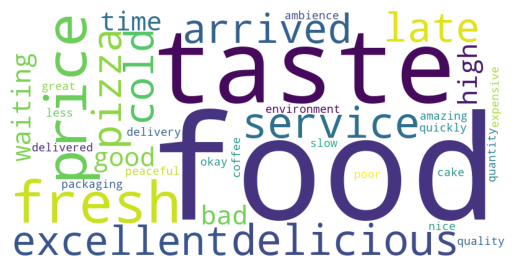

In [12]:
text = " ".join(df['clean_Review_Text'])


wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)



plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [13]:
tfidf = TfidfVectorizer()


X = tfidf.fit_transform(
    df['clean_Review_Text']
)


y = df['Sentiment']

In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = MultinomialNB()


model.fit(
    X_train,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[1.,1.,6.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-2.08,-2.08,-0.29]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](3,)","['Negative','Neutral','Positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 36)","[[0. ,0. ,0. ,...,0. ,0. ,0. ], [0. ,0. ,0. ,...,0. ,0. ,0. ], [0.52,0.52,0. ,...,0.83,0.46,0.46]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 36)","[[-3.64,-3.64,-3.64,...,-3.64,-3.64,-3.64], [-3.64,-3.64,-3.64,...,-3.64,-3.64,-3.64], [-3.46,-3.46,-3.87,...,-3.27,-3.5 ,-3.5 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,36


In [16]:
prediction = model.predict(
    X_test
)


prediction

array(['Positive', 'Positive'], dtype='<U8')

In [17]:
accuracy = accuracy_score(
    y_test,
    prediction
)


print(
"Accuracy:",
accuracy
)

Accuracy: 0.0


In [18]:
new_review=[
"The food was tasty but delivery was very slow"
]


clean = [
clean_text(new_review[0])
]


vector = tfidf.transform(clean)


model.predict(vector)

array(['Positive'], dtype='<U8')